In [25]:
# Load env variables and create client
from dotenv import load_dotenv
from anthropic import Anthropic

load_dotenv()

client = Anthropic()
model = "claude-haiku-4-5"

In [26]:
# Helper functions

from anthropic.types import Message


def add_user_message(messages, message):
    user_message = {
        "role": "user",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(user_message)


def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(assistant_message)


def chat(messages, system=None, temperature=1.0, stop_sequences=[], tools=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if system:
        params["system"] = system

    if tools:
        params["tools"] = tools

    message = client.messages.create(**params)

    return message


def text_from_message(message: Message):
    return "\n".join([block.text for block in message.content if block.type == "text"])

In [27]:
# Tools and Schemas

from datetime import datetime, timedelta


def add_duration_to_datetime(
    datetime_str, duration=0, unit="days", input_format="%Y-%m-%d"
):
    date = datetime.strptime(datetime_str, input_format)

    if unit == "seconds":
        new_date = date + timedelta(seconds=duration)
    elif unit == "minutes":
        new_date = date + timedelta(minutes=duration)
    elif unit == "hours":
        new_date = date + timedelta(hours=duration)
    elif unit == "days":
        new_date = date + timedelta(days=duration)
    elif unit == "weeks":
        new_date = date + timedelta(weeks=duration)
    elif unit == "months":
        month = date.month + duration
        year = date.year + month // 12
        month = month % 12
        if month == 0:
            month = 12
            year -= 1
        day = min(
            date.day,
            [
                31,
                29 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 28,
                31,
                30,
                31,
                30,
                31,
                31,
                30,
                31,
                30,
                31,
            ][month - 1],
        )
        new_date = date.replace(year=year, month=month, day=day)
    elif unit == "years":
        new_date = date.replace(year=date.year + duration)
    else:
        raise ValueError(f"Unsupported time unit: {unit}")

    return new_date.strftime("%A, %B %d, %Y %I:%M:%S %p")


def set_reminder(content, timestamp):
    print(f"----\nSetting the following reminder for {timestamp}:\n{content}\n----")


add_duration_to_datetime_schema = {
    "name": "add_duration_to_datetime",
    "description": "Adds a specified duration to a datetime string and returns the resulting datetime in a detailed format. This tool converts an input datetime string to a Python datetime object, adds the specified duration in the requested unit, and returns a formatted string of the resulting datetime. It handles various time units including seconds, minutes, hours, days, weeks, months, and years, with special handling for month and year calculations to account for varying month lengths and leap years. The output is always returned in a detailed format that includes the day of the week, month name, day, year, and time with AM/PM indicator (e.g., 'Thursday, April 03, 2025 10:30:00 AM').",
    "input_schema": {
        "type": "object",
        "properties": {
            "datetime_str": {
                "type": "string",
                "description": "The input datetime string to which the duration will be added. This should be formatted according to the input_format parameter.",
            },
            "duration": {
                "type": "number",
                "description": "The amount of time to add to the datetime. Can be positive (for future dates) or negative (for past dates). Defaults to 0.",
            },
            "unit": {
                "type": "string",
                "description": "The unit of time for the duration. Must be one of: 'seconds', 'minutes', 'hours', 'days', 'weeks', 'months', or 'years'. Defaults to 'days'.",
            },
            "input_format": {
                "type": "string",
                "description": "The format string for parsing the input datetime_str, using Python's strptime format codes. For example, '%Y-%m-%d' for ISO format dates like '2025-04-03'. Defaults to '%Y-%m-%d'.",
            },
        },
        "required": ["datetime_str"],
    },
}

set_reminder_schema = {
    "name": "set_reminder",
    "description": "Creates a timed reminder that will notify the user at the specified time with the provided content. This tool schedules a notification to be delivered to the user at the exact timestamp provided. It should be used when a user wants to be reminded about something specific at a future point in time. The reminder system will store the content and timestamp, then trigger a notification through the user's preferred notification channels (mobile alerts, email, etc.) when the specified time arrives. Reminders are persisted even if the application is closed or the device is restarted. Users can rely on this function for important time-sensitive notifications such as meetings, tasks, medication schedules, or any other time-bound activities.",
    "input_schema": {
        "type": "object",
        "properties": {
            "content": {
                "type": "string",
                "description": "The message text that will be displayed in the reminder notification. This should contain the specific information the user wants to be reminded about, such as 'Take medication', 'Join video call with team', or 'Pay utility bills'.",
            },
            "timestamp": {
                "type": "string",
                "description": "The exact date and time when the reminder should be triggered, formatted as an ISO 8601 timestamp (YYYY-MM-DDTHH:MM:SS) or a Unix timestamp. The system handles all timezone processing internally, ensuring reminders are triggered at the correct time regardless of where the user is located. Users can simply specify the desired time without worrying about timezone configurations.",
            },
        },
        "required": ["content", "timestamp"],
    },
}

batch_tool_schema = {
    "name": "batch_tool",
    "description": "Invoke multiple other tool calls simultaneously",
    "input_schema": {
        "type": "object",
        "properties": {
            "invocations": {
                "type": "array",
                "description": "The tool calls to invoke",
                "items": {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string",
                            "description": "The name of the tool to invoke",
                        },
                        "arguments": {
                            "type": "string",
                            "description": "The arguments to the tool, encoded as a JSON string",
                        },
                    },
                    "required": ["name", "arguments"],
                },
            }
        },
        "required": ["invocations"],
    },
}

pass

In [28]:
from anthropic.types import ToolParam
import zoneinfo

def get_current_date_time(date_format="%Y-%m-%d %H:%M:%S"):
    if not date_format:
        raise ValueError("Date format cannot be empty")
    return datetime.now(tz=zoneinfo.ZoneInfo("Asia/Kolkata")).strftime(date_format)

# Can work without ToolParam will help prevent a type error down the line

get_current_datetime_schema = ToolParam({
    "name": "get_current_datetime",
    "description": "Returns the current date and time formatted according to the specified format",
    "input_schema": {
        "type": "object",
        "properties": {
            "date_format": {
                "type": "string",
                "description": "A string specifying the format of the returned datetime. Uses Python's strftime format codes.",
                "default": "%Y-%m-%d %H:%M:%S"
            }
        },
        "required": []
    }
})

get_current_date_time()

'2026-03-11 09:55:15'

In [29]:
messages = []

messages.append(
    {"role": "user", "content": "What is the exact time, formatted as HH:MM:SS"}
)

response = client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    tools=[get_current_datetime_schema],
)

response

Message(id='msg_017Td5L11piRdDsbCZ3aeKkn', container=None, content=[ToolUseBlock(id='toolu_01MvJZFjndMAV43b249omeAP', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')], model='claude-haiku-4-5-20251001', role='assistant', stop_reason='tool_use', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=618, output_tokens=63, server_tool_use=None, service_tier='standard'))

In [30]:
messages.append(
    {
        "role":"assistant",
        "content": response.content
    }
)

messages

[{'role': 'user', 'content': 'What is the exact time, formatted as HH:MM:SS'},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_01MvJZFjndMAV43b249omeAP', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]}]

In [31]:
response.content[0]

toolBlock = response.content[0]

toolBlock

ToolUseBlock(id='toolu_01MvJZFjndMAV43b249omeAP', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')

In [32]:
result = get_current_date_time(**response.content[0].input)

In [33]:
messages.append(
    {
        "role":"user",
        "content":[
            {
                "type":"tool_result",
                "tool_use_id": toolBlock.id,
                "content": result,
                "is_error": False
            }
        ]
    }
)

messages

[{'role': 'user', 'content': 'What is the exact time, formatted as HH:MM:SS'},
 {'role': 'assistant',
  'content': [ToolUseBlock(id='toolu_01MvJZFjndMAV43b249omeAP', caller=DirectCaller(type='direct'), input={'date_format': '%H:%M:%S'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01MvJZFjndMAV43b249omeAP',
    'content': '09:55:16',
    'is_error': False}]}]

In [34]:
client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    # Still need to pass tool since we are referring to it, even if it wont use tool here
    tools=[get_current_datetime_schema]
)

Message(id='msg_0149tGYCDGiVf2Mzf5C6phNr', container=None, content=[TextBlock(citations=None, text='The exact time is **09:55:16** (9 hours, 55 minutes, and 16 seconds).', type='text')], model='claude-haiku-4-5-20251001', role='assistant', stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=698, output_tokens=30, server_tool_use=None, service_tier='standard'))

## Using helper functions

In [39]:
messages = []

add_user_message(messages,"Whats the current time in YY HH:MM")

response = client.messages.create(
    model=model,
    max_tokens=1000,
    messages=messages,
    tools=[get_current_datetime_schema]
)

add_assistant_message(messages,response)

response

Message(id='msg_01LMmjKiJrCEcpseq4y2ALQm', container=None, content=[ToolUseBlock(id='toolu_017VeXaJy3FBfifvE18f82eQ', caller=DirectCaller(type='direct'), input={'date_format': '%y %H:%M'}, name='get_current_datetime', type='tool_use')], model='claude-haiku-4-5-20251001', role='assistant', stop_reason='tool_use', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=617, output_tokens=63, server_tool_use=None, service_tier='standard'))

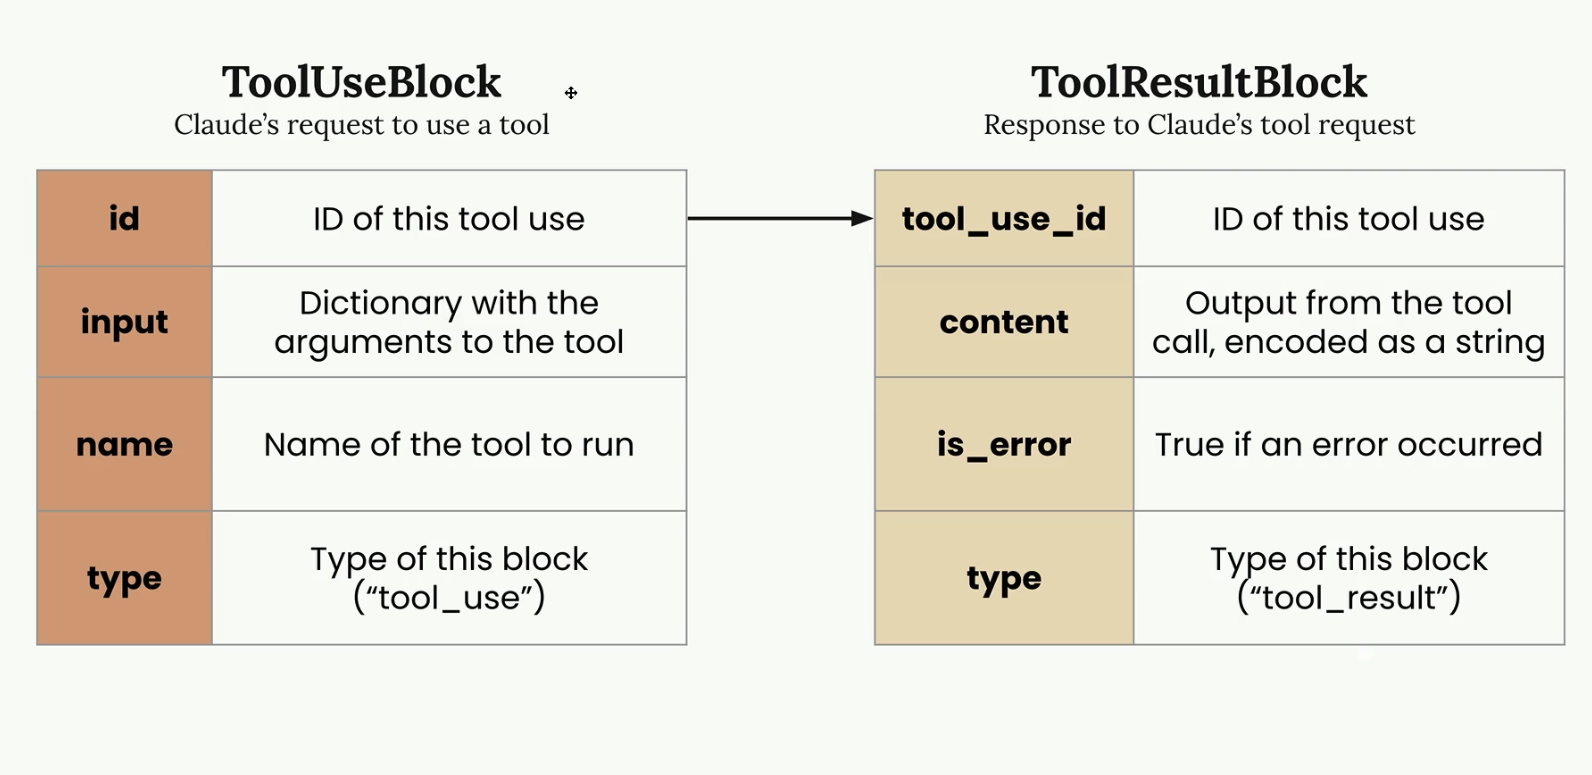

In [58]:
import json


def run_batch(invocations=[]):
    batch_output = []

    for invocation in invocations:
        name = invocation["name"]
        args = json.loads(invocation["arguments"])

        tool_output = run_tool(name, args)

        batch_output.append({"tool_name": name, "output": tool_output})

    return batch_output


def run_tool(tool_name, tool_input):
    if tool_name == "get_current_datetime":
        return get_current_date_time(**tool_input)
    elif tool_name == "set_reminder":
        return set_reminder(**tool_input)
    elif tool_name == "add_duration_to_datetime":
        return add_duration_to_datetime(**tool_input)
    elif tool_name == "batch_tool":
        return run_batch(**tool_input)


def run_tools(message: Message):
    tool_requests = [block for block in message.content if block.type == "tool_use"]

    tool_result_blocks = []

    for tool_request in tool_requests:
        try:
            tool_output = run_tool(tool_request.name, tool_request.input)
            tool_result_block = {
                "type": "tool_result",
                "tool_use_id": tool_request.id,
                "content": json.dumps(tool_output),
                "is_error": False,
            }
        except Exception as e:
            tool_result_block = {
                "type": "tool_result",
                "tool_use_id": tool_request.id,
                "content": f"Error: {e}",
                "is_error": True,
            }

        tool_result_blocks.append(tool_result_block)

    return tool_result_blocks

In [62]:
TOOL_USE_REASON = "tool_use"

tools = [
    get_current_datetime_schema,
    add_duration_to_datetime_schema,
    set_reminder_schema,
    batch_tool_schema
]


def run_conversation(messages):
    while True:
        response = chat(
            messages,
            tools=tools
        )

        add_assistant_message(messages, response)
        print(text_from_message(response))

        if response.stop_reason != TOOL_USE_REASON:
            break

        tool_results = run_tools(response)
        add_user_message(messages, tool_results)

    return messages

In [51]:
messages = []

add_user_message(
    messages,
    "Set a reminder for 3 days from now for my doctors appointment"
)

run_conversation(messages)

I'll help you set a reminder for your doctor's appointment 3 days from now. Let me first get the current date and time, then calculate 3 days from now.
Now let me calculate 3 days from now:
Let me correct that with the proper format:
Now let me set the reminder for that date and time:
----
Setting the following reminder for 2026-03-14T10:11:44:
Doctor's appointment
----
Perfect! I've set a reminder for your doctor's appointment on **Saturday, March 14, 2026 at 10:11 AM** (3 days from now). You'll receive a notification at that time.


[{'role': 'user',
  'content': 'Set a reminder for 3 days from now for my doctors appointment'},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="I'll help you set a reminder for your doctor's appointment 3 days from now. Let me first get the current date and time, then calculate 3 days from now.", type='text'),
   ToolUseBlock(id='toolu_01RrzeVe49BwU2VtY3gFPFNG', caller=DirectCaller(type='direct'), input={}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01RrzeVe49BwU2VtY3gFPFNG',
    'content': '"2026-03-11 10:11:44"',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text='Now let me calculate 3 days from now:', type='text'),
   ToolUseBlock(id='toolu_01WVJUKPhDzpxxCYbLknegLA', caller=DirectCaller(type='direct'), input={'datetime_str': '2026-03-11 10:11:44', 'duration': 3, 'unit': 'days'}, name='add_duration_to_datetime', type='tool_use')]},


In [63]:
messages = []

add_user_message(
    messages,
    "Set a reminder for tomorrow at 8:00 AM for my doctors appointment and one for applying to jobs"
)

run_conversation(messages)

I'll set both reminders for tomorrow at 8:00 AM. Let me first get the current date and time to calculate tomorrow's date.
Now I'll set both reminders for tomorrow (March 12, 2026) at 8:00 AM:
----
Setting the following reminder for 2026-03-12T08:00:00:
Doctor's appointment
----
----
Setting the following reminder for 2026-03-12T08:00:00:
Apply to jobs
----
Perfect! I've set both reminders for tomorrow (Thursday, March 12, 2026) at 8:00 AM:
1. **Doctor's appointment** reminder
2. **Apply to jobs** reminder

Both will notify you at 8:00 AM tomorrow morning.


[{'role': 'user',
  'content': 'Set a reminder for tomorrow at 8:00 AM for my doctors appointment and one for applying to jobs'},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="I'll set both reminders for tomorrow at 8:00 AM. Let me first get the current date and time to calculate tomorrow's date.", type='text'),
   ToolUseBlock(id='toolu_01NbZENM687QJgHV1dGEqNd7', caller=DirectCaller(type='direct'), input={'date_format': '%Y-%m-%d'}, name='get_current_datetime', type='tool_use')]},
 {'role': 'user',
  'content': [{'type': 'tool_result',
    'tool_use_id': 'toolu_01NbZENM687QJgHV1dGEqNd7',
    'content': '"2026-03-11"',
    'is_error': False}]},
 {'role': 'assistant',
  'content': [TextBlock(citations=None, text="Now I'll set both reminders for tomorrow (March 12, 2026) at 8:00 AM:", type='text'),
   ToolUseBlock(id='toolu_01GYsZe3UXcmCPx8RDjKqi4Y', caller=DirectCaller(type='direct'), input={'content': "Doctor's appointment", 'timestamp': '2026-03-12T08:00:00'}, n